# Flood signal saturation study — pipeline v6.0

**Question.** When does a social-media / news layer add information to a physical flood-susceptibility model, and does
that added value shrink as the physical description of the city becomes more complete?

**Design (pre-registered in cell 4).** For every city-event: a physical-completeness ablation ladder (terrain → surface →
hydrography → forcing → SAR; and a second ordering), four fusion architectures (legacy entropy-gated ADR, tuned gate,
stacked late fusion, early fusion), buffered spatial-block cross-validation with blocks sized from the label's own
spatial autocorrelation, toroidal spatial nulls (every effect is null-centred), tile bootstrap, TOST equivalence
verdicts, a population-density placebo, an emotion lens (tone, transformer negativity, distress lexicon, per-source
channels) and a learner-family check. Across cities: random-effects meta-analysis (REML + HKSJ) over every tier-A city,
and the social layer's **localisation** (label-free) as the pre-registered moderator.

### Run it (3 steps)
1. **Runtime → Change runtime type → CPU (High-RAM if available).**
2. Cell 2: check `GCP_PROJECT`. Optional keys go in Colab **Secrets** (key icon): `FLICKR_API_KEY`
   (free, non-commercial: flickr.com/services/apps/create), `YOUTUBE_API_KEY`, `PETABENCANA_API_KEY`.
3. **Runtime → Run all.** Sign in when asked. `RUN_MODE="acquire"` (default) does all network work and saves each city's
   analysis inputs to `MyDrive/saturation_v6/outputs/<city>/` in ≤ 4.5 MB parts; the analysis (`RUN_MODE="analyse"`)
   needs no network and can run anywhere. `"full"` does both in one session.

### Data (real only; nothing synthetic anywhere)
| Layer | Sources | If unavailable |
|---|---|---|
| Grid | OSM boundary ∩ study box, 100 m UTM cells (coarsened only by the pre-registered cell cap) | bounding box (logged) |
| Physical | Copernicus GLO-30, ESA WorldCover, Dynamic World, MERIT Hydro, JRC Surface Water, ERA5-Land, GPM IMERG, Sentinel-1 | that rung is skipped (logged) |
| Labels | per-city chain of event-specific official sources, frozen once as a SHA-256-manifested GeoPackage | next source; city skipped if none passes |
| Social text | GDELT GKG (BigQuery, else public files), Google News RSS, Reddit (Arctic Shift), YouTube (key) — queried in the event's language and English | source skipped (logged) |
| Social geotagged | Flickr (key), Wikimedia Commons (keyless), PetaBencana (Jakarta) | source skipped (logged) |
| Place names | GeoNames populated places (static, CC BY 4.0) with rule t3, then NER + bounded Nominatim | gazetteer only |
| Exposure | GHSL GHS-POP (WorldPop fallback) for the placebo | placebo skipped (logged) |

### What changed in v6 (and why)
* **Self-names vs retrieval aliases.** Until v5.5 the retrieval keywords were also used as the "this is the whole city"
  stop list, so every within-area town listed as a keyword (Paiporta, Catarroja, Kingwood, Humble, Canoas, Lugo, …) was
  deleted from the social layer. v6 keeps a separate `self_names` list per city.
* **Rule t3 for place names** is applied while mentions are resolved: only complete names placed in the study area count.
* **Geotagged photos** (Flickr, Commons) and **localised search terms**; **syndicated wire copies count once**.
* **Localisation as moderator**: every tier-A city is confirmatory; the localisable subset is a secondary analysis.
* **CV blocks from the correlogram**, **learner-family check** (logistic regression), **photo-free sensitivity**.
* **Shared download cache.** `REUSE_V4_DOWNLOADS=True` reuses the frozen ground truth and raw downloads in
  `MyDrive/saturation_v4/` (content-addressed by input hashes and rule versions, so nothing from an older rule set can
  be picked up); outputs, code and pre-registration live in `MyDrive/saturation_v6/`.

Everything is checkpointed: after a disconnect, re-run all cells and it resumes where it stopped.


In [ ]:
#@title 1 · Install packages (≈2 min)
!pip -q install "earthengine-api>=1.0" "google-cloud-bigquery>=3.20" db-dtypes "xgboost>=2.0" "geopandas>=1.0" \
    "pyogrio>=0.7" "pyproj>=3.6" "shapely>=2.0" "osmnx>=1.9" "transformers>=4.40" "scipy>=1.11" "matplotlib" "pyarrow" \
    "rasterio>=1.3" "wordfreq==3.1.1"
import importlib, sys
for mod in ["ee", "google.cloud.bigquery", "xgboost", "geopandas", "pyogrio", "pyproj", "shapely", "osmnx", "transformers",
            "scipy", "rasterio", "wordfreq"]:
    importlib.import_module(mod)
print("packages OK | python", sys.version.split()[0])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 13.0 MB/s eta 0:00:00
packages OK | python 3.13.15


In [ ]:
#@title 2 · Settings (the only cell you normally edit)
GCP_PROJECT = "iconic-elevator-451212-d6"  #@param {type:"string"}
# Order = priority: the agreed core scope (Chennai, Bengaluru) first, then the tier-A replication cities.
RUN_CITIES = "Chennai_2015, Valencia_2024, EmiliaRomagna_2023a, Forli_2023b, York_2015, Carlisle_2015, PortoAlegre_2024, TaquariValley_2024, Houston_SanJacinto_2017, Jakarta_2020"  #@param {type:"string"}
RUN_PROFILE = "full"  #@param ["quick", "medium", "full"]
# "acquire": network stages only (labels, Earth Engine layers, social sources, place names, population); saves each
#            city's analysis inputs to OUT_DIR/<city>/ (+ <= 4.5 MB parts for transfer). Resumable. No model fitting.
# "analyse": reads those inputs; every ladder, null, bootstrap, placebo and the synthesis. No network.
# "full":    both, in one session.
RUN_MODE = "analyse"  #@param ["acquire", "analyse", "full"]
REUSE_V4_DOWNLOADS = True  #@param {type:"boolean"}
USE_BIGQUERY_FOR_GDELT = True  #@param {type:"boolean"}
USE_GDELT_PUBLIC_FILES_IF_NO_BIGQUERY = True  #@param {type:"boolean"}
USE_GOOGLE_NEWS_RSS = True  #@param {type:"boolean"}
USE_REDDIT_ARCTIC_SHIFT = True  #@param {type:"boolean"}
USE_YOUTUBE = True  #@param {type:"boolean"}
USE_PETABENCANA = True  #@param {type:"boolean"}
USE_FLICKR = True  #@param {type:"boolean"}
USE_WIKIMEDIA_COMMONS = True  #@param {type:"boolean"}
USE_TRANSFORMER_NER_AND_NOMINATIM = True  #@param {type:"boolean"}
USE_TRANSFORMER_SENTIMENT = True  #@param {type:"boolean"}
VERIFY_LABEL_SOURCES = True  #@param {type:"boolean"}
FREEZE_LABEL_FILES = True  #@param {type:"boolean"}
USE_FROZEN_LABEL_FILES = True  #@param {type:"boolean"}
REFREEZE_LABEL_FILES = False  #@param {type:"boolean"}
MAX_GEOCODE_CALLS = 1500  #@param {type:"integer"}
# Written into deviations.md only if the pre-registration in OUT_DIR is later changed.
DEVIATION_REASON = ""

import os
from google.colab import drive
drive.mount("/content/drive")
BASE = "/content/drive/MyDrive/saturation_v6"
V4 = "/content/drive/MyDrive/saturation_v4"
OUT_DIR = f"{BASE}/outputs"
if REUSE_V4_DOWNLOADS and os.path.isdir(V4):
    # content-addressed caches: every entry is keyed by its inputs and rule versions, so v6 recomputes whatever
    # changed and reuses only identical work (raw GDELT results, Earth Engine extracts, frozen ground truth)
    CACHE_DIR, ASSETS_DIR = f"{V4}/cache", f"{V4}/label_assets"
else:
    CACHE_DIR, ASSETS_DIR = f"{BASE}/cache", f"{BASE}/label_assets"
for d in (OUT_DIR, CACHE_DIR, ASSETS_DIR):
    os.makedirs(d, exist_ok=True)
CITIES_TO_RUN = [c.strip() for c in RUN_CITIES.split(",") if c.strip()]
print("cities:", CITIES_TO_RUN)
print("profile:", RUN_PROFILE, "| mode:", RUN_MODE, "| outputs:", OUT_DIR)
print("cache:", CACHE_DIR, "| ground truth:", ASSETS_DIR)


Mounted at /content/drive
cities: ['Chennai_2015', 'Valencia_2024', 'EmiliaRomagna_2023a', 'Forli_2023b', 'York_2015', 'Carlisle_2015', 'PortoAlegre_2024', 'TaquariValley_2024', 'Houston_SanJacinto_2017', 'Jakarta_2020']
profile: full | mode: analyse | outputs: /content/drive/MyDrive/saturation_v6/outputs
cache: /content/drive/MyDrive/saturation_v4/cache | ground truth: /content/drive/MyDrive/saturation_v4/label_assets


In [ ]:
#@title 3 · City registry (v6: + self_names) — verified, event-specific ground truth (checked 21 Sep 2026)
# label_chain is tried in order; the first source passing the pre-registered checks is used, and the
# ground-truth TIER of that source is recorded:
#   A_authoritative         official extent products (Copernicus EMS, USGS data releases, EA surveyed outlines, NRSC)
#   A_authoritative_points  official point observations (USGS high-water marks, municipal stagnation points) — sparse
#   B_crowdsourced          crowdsourced reports/maps (PetaBencana, OSM-India) — NOT independent of a social layer
#   C_satellite             satellite-derived references (Sentinel-1/2 change, AI4G, GFD) — not independent ground truth
# Only tier A_authoritative cities enter the confirmatory analysis; the others are reported separately.
#
# Chain entries of the form "file_url:<name>" are separate configurations of one source (several exact files).
# Every URL here was fetched (or confirmed on its official landing page) before it was written down; cell 10
# re-checks them before each run and freezes each city's ground truth into Drive once.
#
# Per-city options:
#   use_bbox_only      True when the flooding crosses municipal boundaries, so no single city polygon fits
#   bounds_from_label  place the grid on the label's own extent (probed before the grid is built)
#   bounds_pad_km      padding around that extent
#   label_search_bounds  where to look for the label when probing
EA_OGC = ("https://environment.data.gov.uk/spatialdata/recorded-flood-outlines/ogc/features/v1/collections/"
          "Recorded_Flood_Outlines/items/")
EMS_S3 = "https://cems-mapping-website.s3.eu-west-1.amazonaws.com/static/activations/"
OPENCITY_CHN15 = "https://data.opencity.in/dataset/866141ab-3a3f-4dc0-8092-421d97ba29a2/resource/"

CITY_REGISTRY = {
  # ======================= tier A: authoritative, event-specific flood extents =======================
  "Valencia_2024": dict(event_date="2024-10-30", lang="es", use_bbox_only=True,
      bounds=dict(min_lon=-0.50, min_lat=39.30, max_lon=-0.30, max_lat=39.50),
      boundary_query=None, aliases=["Valencia", "València", "Paiporta", "Catarroja", "Sedaví", "Alfafar",
                                     "Benetússer", "Massanassa", "Horta Sud"],
      self_names=['Valencia', 'València', 'Horta Sud', "L'Horta Sud", 'Comunitat Valenciana', 'Comunidad Valenciana'],
      subreddits=["es", "spain", "valencia"], news_locale=dict(hl="es", gl="ES", ceid="ES:es"),
      label_chain=["copernicus_ems", "s1_change", "s2_change"],
      label_params=dict(copernicus_ems=dict(code="EMSR773", product_types=("DEL",))),
      note="DANA, 29-31 Oct 2024. EMS EMSR773 delineations (AOI01 Valencia province, AOI03 Horta Sud; images "
           "30 Oct - 8 Nov 2024). Bounding box on purpose: Paiporta, Catarroja, Sedaví sit outside Valencia city."),
  "EmiliaRomagna_2023a": dict(event_date="2023-05-03", lang="it", use_bbox_only=True,
      bounds_from_label=True, bounds_pad_km=2.0,
      bounds=dict(min_lon=11.58, min_lat=44.24, max_lon=12.10, max_lat=44.60),
      label_search_bounds=dict(min_lon=11.50, min_lat=44.10, max_lon=12.20, max_lat=44.75),
      boundary_query=None, aliases=["Faenza", "Lugo", "Bagnacavallo", "Castel Bolognese", "Conselice", "Molinella",
                                     "Lamone", "Sillaro", "Idice", "Romagna", "Emilia-Romagna"],
      self_names=['Romagna', 'Emilia-Romagna', 'Emilia Romagna', 'Lamone', 'Sillaro', 'Idice'],
      subreddits=["italy"], news_locale=dict(hl="it", gl="IT", ceid="IT:it"),
      label_chain=["copernicus_ems", "s1_change", "s2_change"],
      label_params=dict(copernicus_ems=dict(code="EMSR659", product_types=("DEL",))),
      note="FIRST Emilia-Romagna wave, 2-3 May 2023. EMSR659 delineations are imaged 4 May 2023 only, so the "
           "event date is 3 May (v5.3 wrongly paired this label with the 17 May social window)."),
  "Forli_2023b": dict(event_date="2023-05-17", lang="it", use_bbox_only=True,
      bounds_from_label=True, bounds_pad_km=1.5,
      bounds=dict(min_lon=11.95, min_lat=44.17, max_lon=12.12, max_lat=44.27),
      label_search_bounds=dict(min_lon=11.85, min_lat=44.10, max_lon=12.20, max_lat=44.35),
      boundary_query=None, aliases=["Forlì", "Forli", "Romiti", "Roncadello", "Montone", "Ronco", "Romagna",
                                     "Emilia-Romagna"],
      self_names=['Forlì', 'Forli', 'Romagna', 'Emilia-Romagna', 'Emilia Romagna', 'Montone', 'Ronco'],
      subreddits=["italy"], news_locale=dict(hl="it", gl="IT", ceid="IT:it"),
      label_chain=["copernicus_ems", "s1_change", "s2_change"],
      label_params=dict(copernicus_ems=dict(code="EMSR664", aoi_regex=r"AOI0?1\D", product_types=("DEL",))),
      note="SECOND (main) Emilia-Romagna wave, 16-17 May 2023. EMSR664 AOI01 Forlì is the only AOI with "
           "delineation products (images 17-21 May 2023)."),
  "TaquariValley_2024": dict(event_date="2024-05-02", lang="pt", use_bbox_only=True,
      bounds_from_label=True, bounds_pad_km=2.0,
      bounds=dict(min_lon=-51.93, min_lat=-29.32, max_lon=-51.71, max_lat=-29.11),
      label_search_bounds=dict(min_lon=-52.10, min_lat=-29.50, max_lon=-51.60, max_lat=-28.75),
      boundary_query=None, aliases=["Encantado", "Roca Sales", "Muçum", "Arroio do Meio", "Lajeado", "Estrela",
                                     "Colinas", "Vale do Taquari", "Rio Taquari"],
      self_names=['Vale do Taquari', 'Rio Taquari', 'Taquari', 'Rio Grande do Sul'],
      subreddits=["brasil", "riograndedosul"], news_locale=dict(hl="pt-BR", gl="BR", ceid="BR:pt-419"),
      label_chain=["copernicus_ems", "s1_change", "s2_change"],
      label_params=dict(copernicus_ems=dict(code="EMSR720", aoi_regex=r"AOI0?[23]\D", product_types=("DEL",))),
      note="Rio Grande do Sul floods, Taquari valley (Encantado, Roca Sales), 1-2 May 2024. EMSR720 has NO "
           "Porto Alegre AOI: this is the area the v5.3 'PortoAlegre_2024' run actually analysed."),
  "PortoAlegre_2024": dict(event_date="2024-05-05", lang="pt", use_bbox_only=True,
      bounds_from_label=True, bounds_pad_km=1.0,
      bounds=dict(min_lon=-51.30, min_lat=-30.27, max_lon=-51.08, max_lat=-29.93),
      label_search_bounds=dict(min_lon=-51.40, min_lat=-30.30, max_lon=-51.05, max_lat=-29.80),
      boundary_query=None, aliases=["Porto Alegre", "Canoas", "Eldorado do Sul", "Guaíba", "Sarandi", "Humaitá",
                                     "Navegantes", "Menino Deus", "Cidade Baixa", "Arquipélago"],
      self_names=['Porto Alegre', 'Guaíba', 'Guaiba', 'Rio Grande do Sul'],
      subreddits=["brasil", "portoalegre"], news_locale=dict(hl="pt-BR", gl="BR", ceid="BR:pt-419"),
      label_chain=["arcgis_featureserver", "s1_change", "s2_change"],
      label_params=dict(arcgis_featureserver=dict(
          service_url="https://arcgis.jrc.ec.europa.eu/server/rest/services/Hosted/EMSN194_Vector_Layers/FeatureServer",
          layer_regex=r"(?i)extent", aoi_layer_regex=r"(?i)area.?of.?interest")),
      note="Guaíba flood, crest 5 May 2024. CEMS Risk & Recovery EMSN194 (no downloadable files; its vector "
           "layers are served by the JRC FeatureServer). Extent layers dated inside the event window are unioned."),
  "Houston_SanJacinto_2017": dict(event_date="2017-08-29", lang="en", use_bbox_only=True,
      bounds_from_label=True, bounds_pad_km=1.0,
      bounds=dict(min_lon=-95.35, min_lat=29.90, max_lon=-95.05, max_lat=30.15),
      label_search_bounds=dict(min_lon=-95.70, min_lat=29.85, max_lon=-94.95, max_lat=30.45),
      boundary_query=None, aliases=["Kingwood", "Humble", "Atascocita", "Lake Houston", "Huffman", "Porter",
                                     "New Caney", "Conroe", "San Jacinto", "Houston", "Harvey"],
      self_names=['Houston', 'Harvey', 'San Jacinto', 'Lake Houston', 'Harris County'],
      subreddits=["houston"], news_locale=dict(hl="en-US", gl="US", ceid="US:en"),
      label_chain=["usgs_sciencebase", "usgs_stn"],
      label_params=dict(
          usgs_sciencebase=dict(item_id="5aa023ebe4b0b1c392e6881b",
                                file_regex=r"(?i)(polygon|bnd|bound)|\.zip$",
                                file_exclude_regex=r"(?i)(depth|hwm)",
                                # the release ships its layers renamed: sj_final = "Flood inundation polygon"
                                # (RasterToPolygon, gridcode 1), sj_bndy = mapped boundary, sj_hwm = HWM points
                                flood_regex=r"(?i)(polygon|inundat|extent|sj_final)"),
          usgs_stn=dict(event_id=180, states="TX", counties=["Harris County", "Montgomery County"],
                        point_buffer_m=250.0)),
      note="Hurricane Harvey. USGS data release 10.5066/F7VH5N3N covers Harris County ONLY along the San Jacinto "
           "(West/East Fork to Lake Houston Dam); central Houston's bayous are not mapped. Inundation polygons, "
           "with the mapped-area boundary as the valid mask. Fallback: STN high-water marks (event 180)."),
  "NewYork_2021": dict(event_date="2021-09-01", lang="en", use_bbox_only=True,
      bounds=dict(min_lon=-74.17, min_lat=40.57, max_lon=-73.75, max_lat=40.91),
      boundary_query=None, aliases=["New York", "NYC", "Queens", "Brooklyn", "Bronx", "Staten Island", "Manhattan"],
      self_names=['New York', 'NYC', 'New York City', 'City of New York'],
      subreddits=["nyc", "AskNYC"], news_locale=dict(hl="en-US", gl="US", ceid="US:en"),
      label_chain=["usgs_sciencebase", "usgs_stn"],
      label_params=dict(
          usgs_sciencebase=dict(item_id="63badf22d34e92aad3cd279e",
                                file_regex=r"(?i)(depth|inundat|extent)[^/]*\.(tif|tiff|zip)$",
                                file_exclude_regex=r"(?i)(floor|wse|surface.?elev)", depth_min_m=0.0,
                                coverage_hwm=dict(event_id=312, states="NY", buffer_m=250.0,
                                                  counties=["Kings County", "Queens County", "Bronx County",
                                                            "New York County", "Richmond County"])),
          usgs_stn=dict(event_id=312, states="NY",
                        counties=["Kings County", "Queens County", "Bronx County", "New York County", "Richmond County"],
                        point_buffer_m=250.0)),
      note="Remnants of Ida. USGS depth rasters (10.5066/P9JF4OWB) exist only within 250 m of the 83 surveyed HWM "
           "sites and store dry cells as NoData, so the valid mask is the documented 250 m buffer around the STN "
           "HWM sites: the label is LOCAL, not city-wide. No Sentinel-1 fallback (SAR cannot see basement/street "
           "flooding)."),
  "Carlisle_2015": dict(event_date="2015-12-05", lang="en",
      bounds=dict(min_lon=-3.03, min_lat=54.85, max_lon=-2.85, max_lat=54.96),
      boundary_query="Carlisle, Cumbria, England", aliases=["Carlisle", "Cumbria", "Eden", "Storm Desmond"],
      self_names=['Carlisle', 'Cumbria', 'Eden', 'Storm Desmond'],
      subreddits=["unitedkingdom", "CasualUK"], news_locale=dict(hl="en-GB", gl="GB", ceid="GB:en"),
      label_chain=["file_url:ea", "copernicus_ems", "s1_change"],
      label_params={
          "file_url:ea": dict(files=[dict(url=EA_OGC + "Recorded_Flood_Outlines.26355?f=json",
                                          name="EA_RFO_4078182_Carlisle_2015-12-05.geojson")]),
          "copernicus_ems": dict(code="EMSR147", product_regex=None, product_urls=[
              EMS_S3 + "EMSR147/EMSR147_01CARLISLE_DELINEATION_OVERVIEW_v1_vector.zip",
              EMS_S3 + "EMSR147/EMSR147_01CARLISLE_DELINEATION_OVERVIEW-MONIT01_v1_vector.zip"])},
      note="Storm Desmond, 5-7 Dec 2015. Environment Agency Recorded Flood Outline 4078182 (surveyed, OGL v3). "
           "Cross-check: CEMS EMSR147 AOI01 Carlisle."),
  "York_2015": dict(event_date="2015-12-27", lang="en",
      bounds=dict(min_lon=-1.15, min_lat=53.92, max_lon=-1.00, max_lat=54.02),
      boundary_query="York, England", aliases=["York", "Ouse", "Foss", "Storm Eva"],
      self_names=['York', 'Ouse', 'Foss', 'Storm Eva', 'North Yorkshire'],
      subreddits=["unitedkingdom", "CasualUK"], news_locale=dict(hl="en-GB", gl="GB", ceid="GB:en"),
      label_chain=["file_url:ea", "copernicus_ems", "s1_change"],
      label_params={
          "file_url:ea": dict(files=[dict(url=EA_OGC + "Recorded_Flood_Outlines.27083?f=json",
                                          name="EA_RFO_4084890_OuseDerwent_2015-12-25.geojson")]),
          "copernicus_ems": dict(code="EMSR150", product_regex=None, product_urls=[
              EMS_S3 + "EMSR150/EMSR150_01YORK_DELINEATION_OVERVIEW_v1_vector.zip",
              EMS_S3 + "EMSR150/EMSR150_01YORK_DELINEATION_OVERVIEW-MONIT01_v1_vector.zip"])},
      note="Storm Eva, 25-29 Dec 2015. EA outline 4084890 is a grouped Ouse/Derwent outline (reaches Selby); it "
           "is clipped to the York box. Cross-check: CEMS EMSR150 AOI01 York."),
  "Chennai_2015": dict(event_date="2015-12-02", lang="en",
      bounds=dict(min_lon=80.12, min_lat=12.88, max_lon=80.35, max_lat=13.24),
      boundary_query="Chennai, Tamil Nadu, India", aliases=["Chennai", "Madras", "Greater Chennai"],
      self_names=['Chennai', 'Madras', 'Greater Chennai'],
      subreddits=["Chennai", "india"], news_locale=dict(hl="en-IN", gl="IN", ceid="IN:en"),
      label_chain=["file_url:nrsc", "file_url:gcc_points", "file_url:osm_streets", "gfd", "s1_change"],
      label_params={
          "file_url:nrsc": dict(files=[dict(
              url=OPENCITY_CHN15 + "2056abd6-26d7-413b-9dfa-e63cbbf41ee7/download/7cb3cecf-a95a-4786-8032-9c7417655d24.kml",
              name="Chennai2015_NRSC_inundation_zone.kml")], gt_tier="A_authoritative"),
          "file_url:gcc_points": dict(files=[dict(
              url=OPENCITY_CHN15 + "b5f39598-2e2d-40c5-82c3-806a1ad65c91/download/db3840ff-9f33-43a3-b826-2f9dae1bcb78.kml",
              name="Chennai2015_GCC_water_stagnation_points.kml")], point_buffer_m=100.0,
              gt_tier="A_authoritative_points"),
          "file_url:osm_streets": dict(files=[dict(
              url="https://raw.githubusercontent.com/osm-in/flood-map/gh-pages/data/chennai-flooded-streets-Dec2.geojson",
              name="Chennai2015_OSM_flooded_streets_Dec2.geojson", where={"is_flooded": [1, "1", "true", "yes"]})],
              gt_tier="B_crowdsourced"),
          "gfd": dict(dfo_id=4309)},
      note="Dec 2015 floods (peak 1-2 Dec). NRSC inundation zone via the Chennai SDSS on OpenCity (public domain; "
           "image date and sensor NOT stated — report that). Fallbacks: GCC stagnation points, OSM-India flooded "
           "streets (11:00, 2 Dec), GFD DFO 4309 (MODIS 250 m)."),
  # ======================= tier B: crowdsourced labels (not independent of a social layer) =======================
  "Jakarta_2020": dict(event_date="2020-01-01", lang="id",
      bounds=dict(min_lon=106.68, min_lat=-6.37, max_lon=107.00, max_lat=-6.08),
      boundary_query="Daerah Khusus Ibukota Jakarta, Indonesia", aliases=["Jakarta", "DKI Jakarta", "Jabodetabek"],
      self_names=['Jakarta', 'DKI Jakarta', 'Jabodetabek'],
      subreddits=["indonesia", "jakarta"], news_locale=dict(hl="id", gl="ID", ceid="ID:id"),
      petabencana_region="ID-JK",
      label_chain=["petabencana_area", "s1_change", "s2_change"],
      label_params=dict(petabencana_area=dict(point_buffer_m=150.0)),
      note="New-Year 2020 floods. PetaBencana crowdsourced reports (CC BY-NC 4.0) buffered 150 m. Crowdsourced: "
           "PetaBencana is removed from the social layer here and the city is not confirmatory."),
  "Jakarta_2020b": dict(event_date="2020-02-25", lang="id",
      bounds=dict(min_lon=106.68, min_lat=-6.37, max_lon=107.00, max_lat=-6.08),
      boundary_query="Daerah Khusus Ibukota Jakarta, Indonesia", aliases=["Jakarta", "DKI Jakarta", "Jabodetabek"],
      self_names=['Jakarta', 'DKI Jakarta', 'Jabodetabek'],
      subreddits=["indonesia", "jakarta"], news_locale=dict(hl="id", gl="ID", ceid="ID:id"),
      petabencana_region="ID-JK",
      label_chain=["petabencana_area", "s1_change", "s2_change"],
      label_params=dict(petabencana_area=dict(point_buffer_m=150.0)),
      note="Second Jakarta event (25 Feb 2020): same city, independent event, same caveats."),
  # ======================= tier C: satellite-derived references (scoped Indian cities) =======================
  "Chennai_2021": dict(event_date="2021-11-07", lang="en",
      bounds=dict(min_lon=80.12, min_lat=12.88, max_lon=80.35, max_lat=13.24),
      boundary_query="Chennai, Tamil Nadu, India", aliases=["Chennai", "Madras", "Greater Chennai"],
      self_names=['Chennai', 'Madras', 'Greater Chennai'],
      subreddits=["Chennai"], label_chain=["ai4g_sar", "s1_change", "s2_change"],
      note="Nov 2021 floods. No open vector ground truth exists (checked: CEMS, UNOSAT, NDEM, Sentinel Asia, "
           "OpenCity). Microsoft AI4G Sentinel-1 detections (tile N12E078), then our own S1/S2 change."),
  "Chennai_2023": dict(event_date="2023-12-04", lang="en",
      bounds=dict(min_lon=80.12, min_lat=12.88, max_lon=80.35, max_lat=13.24),
      boundary_query="Chennai, Tamil Nadu, India", aliases=["Chennai", "Madras", "Michaung"],
      self_names=['Chennai', 'Madras', 'Michaung'],
      subreddits=["Chennai"], label_chain=["ai4g_sar", "s2_change", "s1_change"],
      note="Cyclone Michaung. NRSC's EOS-04 extent is PDF-only (not public). Satellite references only; may "
           "fail for lack of a Sentinel-1 pass (S1A only) — kept as a documented negative if so."),
  "Bengaluru_2022": dict(event_date="2022-09-05", lang="en",
      bounds=dict(min_lon=77.55, min_lat=12.85, max_lon=77.80, max_lat=13.10),
      boundary_query="Bengaluru, Karnataka, India",
      aliases=["Bengaluru", "Bangalore", "BBMP", "Mahadevapura", "Bellandur"],
      self_names=['Bengaluru', 'Bangalore', 'BBMP'],
      subreddits=["bangalore"], label_chain=["ai4g_sar", "s1_change", "s2_change"],
      note="Sept 2022 Outer Ring Road floods. Event-specific flooded-location data are not public (OpenCity, "
           "2022); BBMP/KSRSAC lists are static flood-prone sites, not event truth. AI4G tile N12E075, then S1/S2."),
  "Bengaluru_2024": dict(event_date="2024-10-22", lang="en",
      bounds=dict(min_lon=77.45, min_lat=12.80, max_lon=77.80, max_lat=13.15),
      boundary_query="Bengaluru, Karnataka, India", aliases=["Bengaluru", "Bangalore", "BBMP", "Yelahanka"],
      self_names=['Bengaluru', 'Bangalore', 'BBMP'],
      subreddits=["bangalore"], label_chain=["s1_change", "s2_change"],
      note="Oct 2024 Yelahanka floods. After AI4G's coverage (ends Sep 2024); own S1/S2 change only. The "
           "official 'flood_prone_locations' KML is a static list and is no longer used as a label."),
}
RENAMED = {"Houston_2017": "Houston_SanJacinto_2017", "EmiliaRomagna_2023": "EmiliaRomagna_2023a"}
for _old, _new in RENAMED.items():
    if _old in CITIES_TO_RUN:
        print(f"note: {_old} is now {_new} (see its note)")
        CITIES_TO_RUN = [_new if c == _old else c for c in CITIES_TO_RUN]
unknown = [c for c in CITIES_TO_RUN if c not in CITY_REGISTRY]
assert not unknown, f"Not in registry: {unknown}. Available: {list(CITY_REGISTRY)}"
for c in CITIES_TO_RUN:
    r = CITY_REGISTRY[c]
    print(f"{c:<24} {r['event_date']}  labels={r['label_chain']}"
          + (f"  grid={r['grid_m']}m" if r.get("grid_m") else ""))
    print(f"{'':<24} {r['note']}")
LIVE_VECTOR_SOURCES = ("copernicus_ems", "usgs_sciencebase", "portal_download", "official", "petabencana_area",
                       "file_url", "usgs_stn", "arcgis_featureserver")
if USE_FROZEN_LABEL_FILES:
    # read the frozen GeoPackage first; the live sources stay in the chain as the fallback
    for _c in CITIES_TO_RUN:
        _cfg = CITY_REGISTRY[_c]
        if "canonical_gpkg" in _cfg["label_chain"]:
            continue
        _live = next((s for s in _cfg["label_chain"] if s.split(":")[0] in LIVE_VECTOR_SOURCES), None)
        if _live is None:
            continue
        _pb = ((_cfg.get("label_params") or {}).get(_live, {}) or {}).get("point_buffer_m", 0.0)
        _cfg["label_chain"] = ["canonical_gpkg"] + list(_cfg["label_chain"])
        _cfg.setdefault("label_params", {})["canonical_gpkg"] = dict(assets_root=ASSETS_DIR, point_buffer_m=_pb)
    print("label chains:", {c: CITY_REGISTRY[c]["label_chain"][:3] for c in CITIES_TO_RUN})


Chennai_2015             2015-12-02  labels=['file_url:nrsc', 'file_url:gcc_points', 'file_url:osm_streets', 'gfd', 's1_change']
                         Dec 2015 floods (peak 1-2 Dec). NRSC inundation zone via the Chennai SDSS on OpenCity (public domain; image date and sensor NOT stated — report that). Fallbacks: GCC stagnation points, OSM-India flooded streets (11:00, 2 Dec), GFD DFO 4309 (MODIS 250 m).
Valencia_2024            2024-10-30  labels=['copernicus_ems', 's1_change', 's2_change']
                         DANA, 29-31 Oct 2024. EMS EMSR773 delineations (AOI01 Valencia province, AOI03 Horta Sud; images 30 Oct - 8 Nov 2024). Bounding box on purpose: Paiporta, Catarroja, Sedaví sit outside Valencia city.
EmiliaRomagna_2023a      2023-05-03  labels=['copernicus_ems', 's1_change', 's2_change']
                         FIRST Emilia-Romagna wave, 2-3 May 2023. EMSR659 delineations are imaged 4 May 2023 only, so the event date is 3 May (v5.3 wrongly paired this label with the 17 May

In [ ]:
#@title 4 · Pre-registration (analysis plan fixed before data are touched)
# v6.0: see analysis_plan['fixed'] for what had been seen when it was written. Any later change is
# recorded automatically in OUT_DIR/deviations.md with the reason given in cell 2.
PREREG = {'version': 'v6.0-2026-09',
 'grid_m': 100,
 'max_cells': 260000,
 'grid_m_escalation': [100, 150, 200, 250],
 'grid_rule': 'the smallest listed cell size whose bounding box fits max_cells is used; because the box is an '
              'upper bound on cells inside the study area, the cap can never be breached after the choice',
 'label': {'point_rule': 'containing cell',
           'polygon_rule': 'cell centre within polygon',
           'sensitivity_point_buffer_m': 100,
           'event_window_days': [-2, 10],
           'sources': ['copernicus_ems (EMS Rapid Mapping delineation polygons)',
                       'usgs_sciencebase (USGS data release: inundation polygons or high-water marks)',
                       'portal_download (open-data portal file, filtered to the event window)',
                       'petabencana_area (RW-level flooded areas, else buffered reports)',
                       'official (municipal file)',
                       'gfd (Global Flood Database, events <= 2018)',
                       's1_change (Sentinel-1)',
                       's2_change (Sentinel-2 MNDWI)'],
           'prevalence_bounds': [0.0005, 0.6],
           'min_positive_cells': 50,
           'flag_prevalence_above': 0.35,
           'valid_cell_fraction': 0.5,
           'exclude_permanent_water_occ': 50,
           'observable_rule': 'EMS: inside the activation AOI; S1/S2: observed in both periods; USGS: inside '
                              'the product footprint',
           'ems_layer_regex': 'observed_event|flooded_area|flood_extent|inundat '
                              '(hydrography/facilities/settlements dropped)',
           'ems_max_packages': 12,
           'sciencebase_max_files': 8,
           'report_buffer_m': 250,
           'report_window_days': [-1, 3],
           'min_reports': 30,
           's1_change': {'baseline_days': [-40, -10],
                         'event_days': [-2, 12],
                         'diff_db': -3.0,
                         'event_db': -16.0,
                         'jrc_occurrence_max': 50,
                         'slope_max_deg': 5.0,
                         'hand_max_m': 15.0,
                         'cell_fraction': 0.25},
           's2_change': {'baseline_days': [-90, -15],
                         'event_days': [1, 12],
                         'cloud_prob_max': 40,
                         'mndwi_threshold': 0.0,
                         'jrc_occurrence_max': 50,
                         'slope_max_deg': 5.0,
                         'hand_max_m': 15.0,
                         'cell_fraction': 0.25,
                         'min_clear_fraction': 0.5}},
 'physical_groups': {'terrain': ['elev_m', 'slope_deg', 'tpi_1km'],
                     'surface': ['built_frac', 'tree_frac', 'dw_built'],
                     'hydrography': ['hand_m', 'log_upa', 'dist_water_m', 'jrc_occ'],
                     'forcing': ['era5_rain_72h', 'era5_rain_ante7d', 'era5_sm_l1', 'imerg_rain_72h'],
                     'sar_event': ['s1_vv_drop_db']},
 'orderings': {'A_terrain_first': ['terrain', 'surface', 'hydrography', 'forcing', 'sar_event'],
               'B_surface_first': ['surface', 'forcing', 'terrain', 'hydrography', 'sar_event']},
 'social': {'sources': ['gdelt_bigquery',
                        'gdelt_rawfiles',
                        'google_news_rss',
                        'reddit_arcticshift',
                        'youtube',
                        'petabencana',
                        'flickr',
                        'wikimedia_commons'],
            'window_days': [-1, 2],
            'sensitivity_window_days': [-3, 3],
            'kde_bandwidth_m': 2500,
            'sensitivity_bandwidth_m': 1000,
            'transform': 'log1p(mentions per km2)',
            'primary_channel': 'S_mentions',
            'emotion_channels': ['S_negative (GDELT tone or transformer negativity)',
                                 'S_distress (lexicon)',
                                 'S_src_* (per source)'],
            'min_source_mentions': 10,
            'max_bq_gb': 120,
            'outside_places_buffer_km': 80,
            'gdelt_text': 'title (from 2019-09-22) + URL slug + GKG location names; earlier events have no '
                          'titles',
            'geoparsing': {'version': 'g3',
                           'added': 'v6 (applied to every city)',
                           'gazetteer': 'GeoNames country extract (download.geonames.org/export/dump/<CC>.zip, '
                                        'CC BY 4.0), feature class P codes PPL, PPLX, PPLL, PPLF, PPLS, '
                                        'PPLA2-5 inside the study area (name, ASCII name and Latin-script '
                                        'alternate names); generic words, major places, names used > 2 km '
                                        'apart and names shared with towns outside the area removed. v5.5.1: '
                                        'replaces the OSM/Overpass gazetteer, which was unavailable for 7 of 9 '
                                        'cities in v5.5.0. v6: the GeoNames feature that IS the study '
                                        'city/region (any of its names equal to a self-name) is excluded with '
                                        'all its alternate names',
                           'outside_places': 'GeoNames populated places (population >= 1000, not sections) '
                                             'within outside_places_buffer_km of the study area but outside it',
                           'ner_geocoding': 'Nominatim, bounded to the study box, up to 5 candidates; accepted '
                                            'only if a settlement unit (suburb ... town) whose name equals the '
                                            'NER name, accents ignored; streets, POIs, rivers and '
                                            'administrative areas never accepted; v6: the query is the name '
                                            'alone (bounded box), not name + alias',
                           'dropped': "month and weekday names; the study city's own names; major cities, "
                                      'regions, countries',
                           'diagnostic': 'effective number of mention locations (1/HHI) and top-place share, '
                                         'logged and written to provenance',
                           'self_names': 'names denoting the whole study area (city, region, storm, main '
                                         'river) are retrieval keywords only, never locations; v5 wrongly used '
                                         'the retrieval alias list here, which removed every within-area town '
                                         'listed as an alias from the social layer',
                           'toponym_rule': 't3: a gazetteer match counts only if the text holds an occurrence '
                                           'that is either a GDELT-structured location placed in the study '
                                           "area ('<name>, <home region/country>') or a capitalised, complete "
                                           'name in prose (no adjacent feature word or name particle, no '
                                           'adjacent capitalised word outside title-case headlines, no '
                                           "qualifier placing it elsewhere, not a common word of the city's "
                                           'language or English at Zipf >= 4.5); names that are countries, '
                                           'continents or first-level divisions of the study country never '
                                           'count; lower-case occurrences (URL words) do not count on their '
                                           'own',
                           'location_unit': 'mentions are counted on a ~250 m lattice (0.0025 deg) for every '
                                            'resolution path'},
            'query_terms': 'keyword APIs (news RSS, Reddit comments, YouTube) are queried with the event '
                           "language's flood terms and English: es inundación/DANA/riada, it "
                           'alluvione/allagamento/esondazione, pt enchente/inundação/alagamento, id '
                           'banjir/genangan, en flood/flooding/waterlogging',
            'geotagged_photos': {'sources': 'Flickr (flickr.photos.search, has_geo, API key) and Wikimedia '
                                            'Commons (geosearch, keyless)',
                                 'rule': 'photo TAKEN inside the social window, inside the study box, with '
                                         'flood vocabulary in its title, tags, description or categories; '
                                         'Flickr location accuracy >= 12 (neighbourhood or finer)',
                                 'dedupe': 'one photo per author, ~100 m spot and day',
                                 'timeliness': 'photos may be uploaded after the event; they measure where '
                                               'flooding was photographed, not what was known in real time '
                                               '(stated as a limitation; a sensitivity analysis drops them)'},
            'deduplication': '(1) syndicated wire copies: identical GDELT location list, tone vector and title '
                             'count once; (2) identical text (160 normalised characters) counts once; (3) '
                             'photos as above'},
 'cv': {'k_folds': 5,
        'tile_m': 2000,
        'buffer_m': 500,
        'inner_k': 3,
        'seed': 42,
        'tile_rule': 'correlogram',
        'tile_max_m': 4000,
        'min_positive_tiles_per_fold': 3,
        'tile_rule_text': 'tile = correlogram range (autocorrelation < 0.1) minus the buffer, rounded up to '
                          '500 m, within [tile_m, tile_max_m]; stepped down by 500 m while fewer than 3 x k '
                          'tiles contain flooded cells (Roberts et al. 2017)'},
 'model': {'kind': 'xgb',
           'params': {'n_estimators': 400,
                      'max_depth': 6,
                      'learning_rate': 0.05,
                      'subsample': 0.8,
                      'colsample_bytree': 0.8,
                      'min_child_weight': 5,
                      'reg_lambda': 1.0}},
 'computation': {'checkpointing': 'every stage and every ladder rung is written to cache/ as soon as it '
                                  'finishes; a disconnected run resumes instead of restarting',
                 'rung_reuse': 'rungs with identical feature sets are computed once and reused across '
                               'orderings',
                 'missing_data': 'coarse reanalysis gaps are filled from the nearest valid cell, never a city '
                                 'median',
                 'per_city_grid': 'grid_m may be raised for a study area too large at 100 m; reported per '
                                  'city'},
 'inference': {'n_null_toroidal': 99,
               'n_null_toroidal_early': 25,
               'null_min_shift_m': 5000,
               'n_boot_tiles': 500,
               'alpha': 0.05,
               'note': 'early fusion gets its own (smaller) toroidal null because each shift needs XGBoost '
                       'refits',
               'gated_grid': {'alphas': [0.0, 0.25, 0.5, 1.0, 2.0],
                              'taus': [0.3, 0.5, 0.7],
                              'rule': '(alpha, tau) chosen on training tiles by AP; alpha = 0 always '
                                      'admissible'}},
 'robustness': {'added': 'v5.4.1, after the Chennai_2015 and Valencia_2024 runs; reported as robustness, never '
                         'as primary',
                'gradient_excluding_R0': 'primary gradients recomputed without R0 (no physical features); role '
                                         'robust_excl_R0',
                'gated_wide_grid': 'most complete rung refitted with alphas 0..6 and taus 0 (= ungated) ..0.7; '
                                   'reports how often the gate is used, switched off, or replaced by ungated '
                                   'addition',
                'fold_diagnostics': 'per-fold cells, positives and prevalence (fold_diagnostics.csv); flagged '
                                    'when the range exceeds 25 percentage points',
                'learner_logistic': 'most complete rung refitted with a standardised logistic regression as '
                                    'the physical learner (all operators, nulls and bootstrap), so verdicts do '
                                    'not hinge on XGBoost',
                'without_photos': 'top rung refitted without the geotagged photo sources (timeliness check)'},
 'label_ai4g': {'pixel_m': 20.0,
                'cell_fraction': 0.25,
                'card_filters': True,
                'note': 'AI4G detections inside the event window; a cell is flooded when detections cover >= '
                        "25% of it (20 m pixels assumed, per the dataset's Sentinel-1 input resolution)"},
 'analysis_plan': {'fixed': '29 Sep 2026, v6, before any v6 acquisition. Seen at that point: v5.5.2 '
                            'localisation statistics (label-free) and v5.5.0 results for Chennai_2015 and the '
                            'architecture effects',
                   'research_questions': {'RQ1': 'At the most complete physical rung, does each fusion '
                                                 'operator (legacy entropy-gated ADR, tuned gated, stacked '
                                                 'late fusion, early fusion) change held-out AP? Pooled across '
                                                 'cities by random-effects meta-analysis. Confirmatory set: '
                                                 'every tier-A city.',
                                          'RQ2': "Within a city, does the social layer's marginal value "
                                                 'decline as physical completeness rises? Slope of the '
                                                 'null-centred gain on held-out physical AP across the ordered '
                                                 'ladder, tile-bootstrap CI, one-sided test.',
                                          'RQ3': "Is the social layer's value general across cities, and what "
                                                 'explains its variation? (a) random-effects meta-analysis of '
                                                 'the per-city slopes and top-rung effects over every tier-A '
                                                 "city; (b) pre-registered moderator: the social layer's "
                                                 'localisation (log effective number of mention locations, '
                                                 'label-free) in a mixed-effects meta-regression (REML, '
                                                 'Knapp-Hartung, permutation p); (c) the localisable subset '
                                                 'pooled as a conditional secondary analysis, whatever its '
                                                 'size.'},
                   'co_primary_endpoints': ['info_nats_fm_adj (cross-validated estimate of I(Y;S|R), the '
                                            'quantity the saturation definition is about)',
                                            'dAP_stacked_fm_adj (operational ranking value)'],
                   'secondary_endpoints': ['dAP_gated_fm, dAP_early_fm_adj, dAP_adr_legacy_fm (architectures, '
                                           'RQ1)',
                                           'headroom-normalised gradients info_frac_fm_adj = I/H(Y|R) and '
                                           'dAPh_fm_adj = dAP/(1-AP)',
                                           'all gradients without R0; ordering B'],
                   'primary_ordering': 'A_terrain_first (B_surface_first is a robustness check of ordering '
                                       'dependence)',
                   'confirmatory_set': 'gt_tier == A_authoritative (all such cities, localisable or not). v5.5 '
                                       'restricted the confirmatory set to localisable cities; v6 keeps '
                                       'localisation as the moderator instead, so no city is excluded on a '
                                       'property of its social layer',
                   'localisation_eligibility': {'min_mentions': 100,
                                                'min_effective_locations': 10,
                                                'max_top_place_share': 0.4,
                                                'basis': 'label-free: computed from the located mentions in '
                                                         'the primary window only (effective locations = '
                                                         '1/Herfindahl index of mention locations). Selecting '
                                                         'on R0 information gain instead would bias the slope '
                                                         'downward (regression to the mean at the first rung), '
                                                         'so it is never used for selection.',
                                                'role': 'defines the conditional secondary set and the '
                                                        'forest-plot marking only'},
                   'multiplicity': 'Holm across (tier-A cities) x (2 co-primary endpoints), ordering A, '
                                   'one-sided slope tests; headline tests: pooled RQ3 slope (confirmatory set) '
                                   'and the localisation moderator',
                   'meta_analysis': 'REML tau^2 (fixed-point), Hartung-Knapp-Sidik-Jonkman CI with max(1,q) '
                                    'truncation (k < 10), I^2, 95% prediction interval (k >= 3); per-city SE = '
                                    'tile-bootstrap SD of the slope',
                   'sesoi': {'dAP_stacked_fm': 0.01,
                             'dAP_gated_fm': 0.01,
                             'dAP_early_fm': 0.01,
                             'dAP_adr_legacy_fm': 0.01,
                             'info_frac_fm': 0.02},
                   'sesoi_rationale': '0.01 AP: below the between-fold AP sd of every physical model in the '
                                      'v5.3-v5.4 runs and below operational relevance for ranking cells; 0.02 '
                                      "of the physical model's remaining held-out uncertainty for information",
                   'equivalence': "'saturated' only if the 90% tile-bootstrap interval of the null-centred "
                                  "effect lies inside +/- SESOI (TOST at 5%); 'informative' needs the 95% "
                                  "interval above 0 and p_null <= 0.05; 'harmful' needs the 95% interval below "
                                  "0; otherwise 'inconclusive'",
                   'density_placebo': True,
                   'density_placebo_design': 'GHSL GHS-POP (epoch nearest the event; WorldPop fallback) '
                                             'smoothed with the social kernel and transform replaces the '
                                             'social layer through the full ordering-A ladder (same folds, '
                                             'nulls, bootstrap; no early fusion). A decline that a pure '
                                             'population layer also shows is not evidence about event '
                                             "information. Control: the real social layer's gain at the top "
                                             'rung with population added to the physical model.',
                   'blocking_check': 'label correlogram per city; the distance at which autocorrelation drops '
                                     'below 0.1 is compared with tile + buffer (2.5 km) and reported',
                   'exploratory': 'meta-regression on physical lift and log mentions (descriptive)',
                   'moderator': {'name': 'log_effective_locations',
                                 'outcomes': ['gradient slopes (co-primary)', 'top-rung effects (RQ1 metrics)'],
                                 'test': 'two-sided; permutation p reported and used for k < 10',
                                 'expectation': 'none pre-specified in sign for slopes; positive for top-rung '
                                                'gains'}},
 'reporting': {'primary': 'per-fold metrics (mean over the 5 spatial folds), null-centred: the reported effect '
                          'is the observed value minus the mean of the toroidal-null replicates',
               'primary_metrics': ['info_nats_fm_adj',
                                   'dAP_stacked_fm_adj',
                                   'dAP_early_fm_adj',
                                   'dAP_gated_fm'],
               'gradient_x': 'AP_recal_fm (per-fold physical skill)',
               'secondary': 'pooled out-of-fold metrics and the headroom-normalised dAPh_stacked, reported for '
                            'continuity; the headroom denominator (1-AP) shrinks along the ladder and '
                            'amplifies late rungs',
               'why_null_centred': 'a toroidal-shifted social layer carries no flood information yet still '
                                   'moves AP a little (an extra smooth channel helps the learner), so raw '
                                   'deltas overstate the real gain',
               'completeness': 'all cities, rungs, orderings, channels, sensitivity variants and the '
                               'localisation audit (T9) are reported, including null results'},
 'ground_truth': {'tiers': {'A_authoritative': 'official event extent (CEMS, USGS data release, EA surveyed '
                                               'outline, NRSC)',
                            'A_authoritative_points': 'official point observations (USGS high-water marks, '
                                                      'municipal points); sparse',
                            'B_crowdsourced': 'crowdsourced reports/maps; not independent of a social layer',
                            'C_satellite': 'satellite-derived reference (Sentinel-1/2 change, AI4G, GFD); not '
                                           'independent truth'},
                  'confirmatory_tier': 'A_authoritative',
                  'event_specificity': 'Copernicus EMS products are kept only if their satellite image was '
                                       'acquired inside the label event window; ArcGIS extent layers only if '
                                       'their date is inside it; EA outlines are selected by their record id',
                  'unmapped_cells': "cells outside a product's mapped area (EMS area of interest, USGS "
                                    'mapped-area boundary, depth-raster footprint, AI4G exclusion layer) are '
                                    'excluded as unknown, never scored as dry',
                  'circularity': ['a Sentinel-1-derived label (s1_change, ai4g_sar) removes the Sentinel-1 '
                                  'rung from every ladder',
                                  'a PetaBencana label removes PetaBencana from the social layer'],
                  'frozen_files': "each city's vector ground truth is downloaded once and stored as one "
                                  "canonical GeoPackage (WGS84; layers 'labels' and 'coverage') with a SHA-256 "
                                  'manifest; runs read that file, so labels cannot change silently between '
                                  'runs',
                  'verification': 'every documented source URL is checked before the run and written to '
                                  'label_sources_status.csv'}}
print('pre-registration', PREREG['version'], 'ready:', len(PREREG['physical_groups']), 'physical groups,',
      len(PREREG['social']['sources']), 'social sources')


pre-registration v6.0-2026-09 ready: 5 physical groups, 8 social sources


In [ ]:
#@title 5 · Load the pipeline code from Drive (SHA-256 checked)
# The tested modules live in MyDrive/saturation_v6/code/ (large ones in parts). Each module is reassembled and its
# SHA-256 compared with the value pinned below; a missing, edited or damaged file is refused rather than run.
import hashlib, os, sys
CODE_MANIFEST = {
 "toponym_data": {
  "files": [
   "toponym_data.py"
  ],
  "sha256": "90c5996202803724f9e2033c65f9b88684bfbd0781a5f1b2a830331a9e382a71"
 },
 "pipeline_helpers": {
  "files": [
   "pipeline_helpers.py"
  ],
  "sha256": "675758f2ea0f676bcb3cbd089cfefd70b6db404ce9a9d200f6b7ff768fc62cff"
 },
 "saturation_core": {
  "files": [
   "saturation_core.py"
  ],
  "sha256": "2419c2aaf3fd9eca7301ce0fa9206446080c132ae0118cb6a84ee9681dd56746"
 },
 "data_sources": {
  "files": [
   "data_sources.part01of05.py",
   "data_sources.part02of05.py",
   "data_sources.part03of05.py",
   "data_sources.part04of05.py",
   "data_sources.part05of05.py"
  ],
  "sha256": "69577756692f960188e3d101f110d4ce8db2443f29f2a0f688f9c9b48960c829"
 },
 "orchestrator": {
  "files": [
   "orchestrator.part01of03.py",
   "orchestrator.part02of03.py",
   "orchestrator.part03of03.py"
  ],
  "sha256": "cb4db74c189bfa526ec048d8807faa8d549de96693b59863e99a7d38da1ceb9f"
 }
}
CODE_DIR = f"{BASE}/code"
LOCAL_CODE = "/content/saturation_code_v6"

def _norm(t):
    return t.replace("\r\n", "\n").rstrip() + "\n"

if not os.path.isdir(CODE_DIR):
    raise FileNotFoundError(f"{CODE_DIR} not found: copy the 'code' folder of the v6 release into MyDrive/saturation_v6/")
os.makedirs(LOCAL_CODE, exist_ok=True)
for _mod, _spec in CODE_MANIFEST.items():
    _missing = [f for f in _spec["files"] if not os.path.exists(os.path.join(CODE_DIR, f))]
    if _missing:
        raise FileNotFoundError(f"{_mod}: missing {_missing} in {CODE_DIR}")
    _text = _norm("".join(_norm(open(os.path.join(CODE_DIR, f), encoding="utf-8").read()) for f in _spec["files"]))
    _h = hashlib.sha256(_text.encode()).hexdigest()
    if _h != _spec["sha256"]:
        raise RuntimeError(f"{_mod}: SHA-256 {_h[:16]}… does not match the released code ({_spec['sha256'][:16]}…); "
                           f"the files in {CODE_DIR} were edited or damaged. Restore them from the release.")
    open(os.path.join(LOCAL_CODE, f"{_mod}.py"), "w", encoding="utf-8").write(_text)
if LOCAL_CODE not in sys.path:
    sys.path.insert(0, LOCAL_CODE)
for _m in list(CODE_MANIFEST):
    sys.modules.pop(_m, None)          # re-running this cell always loads the verified files
import toponym_data, pipeline_helpers, saturation_core
print("code verified:", {m: s["sha256"][:12] for m, s in CODE_MANIFEST.items()})


code verified: {'toponym_data': '90c599620280', 'pipeline_helpers': '675758f2ea0f', 'saturation_core': '2419c2aaf3fd', 'data_sources': '69577756692f', 'orchestrator': 'cb4db74c189b'}


In [ ]:
#@title 6 · Word lists, grid, label and text helpers (verified in cell 5)
import toponym_data, pipeline_helpers
print('helpers loaded; common-word lists match the pre-registered SHA-256')


helpers loaded; common-word lists match the pre-registered SHA-256


In [ ]:
#@title 7 · Data-source connectors (verified in cell 5)
import data_sources
print('data_sources loaded')


data_sources loaded


In [ ]:
#@title 8 · Orchestrator (verified in cell 5)
import orchestrator
print('orchestrator loaded, pipeline', orchestrator.PIPELINE_VERSION)


orchestrator loaded, pipeline v6.0.0


In [ ]:
#@title 9 · Sign in and preflight checks (unavailable optional sources are switched off, never faked)
import os, sys, time, requests, pandas as pd
import data_sources as ds
LOG = ds.RunLog(path=f"{OUT_DIR}/run_log.csv")
checks = []

def check(name, fn):
    t = time.time()
    try:
        detail = fn(); checks.append(dict(check=name, ok=True, detail=str(detail)[:120], sec=round(time.time() - t, 1)))
    except Exception as e:
        checks.append(dict(check=name, ok=False, detail=f"{type(e).__name__}: {str(e)[:160]}", sec=round(time.time() - t, 1)))

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import auth
    auth.authenticate_user()

import ee
def _ee():
    try:
        ee.Initialize(project=GCP_PROJECT)
    except Exception:
        ee.Authenticate(); ee.Initialize(project=GCP_PROJECT)
    return ee.Number(1).add(1).getInfo()
check("Earth Engine", _ee)
EE_OK = checks[-1]["ok"]

BQ_CLIENT = None
def _bq():
    global BQ_CLIENT
    from google.cloud import bigquery
    client = bigquery.Client(project=GCP_PROJECT)
    job = client.query("SELECT COUNT(*) FROM `gdelt-bq.gdeltv2.gkg_partitioned` WHERE _PARTITIONTIME = TIMESTAMP('2020-01-01')",
                       job_config=bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
    BQ_CLIENT = client
    return f"dry run OK ({job.total_bytes_processed/1e9:.2f} GB)"
if USE_BIGQUERY_FOR_GDELT:
    check("BigQuery (GDELT)", _bq)

def secret(name):
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return os.environ.get(name)
YOUTUBE_KEY, PETA_KEY, FLICKR_KEY = secret("YOUTUBE_API_KEY"), secret("PETABENCANA_API_KEY"), secret("FLICKR_API_KEY")

for name, url in [("GDELT public files", "http://data.gdeltproject.org/gdeltv2/lastupdate.txt"),
                  ("Google News RSS", "https://news.google.com/rss/search?q=flood"),
                  ("Arctic Shift (Reddit)", "https://arctic-shift.photon-reddit.com/api/posts/search?subreddit=bangalore&limit=1"),
                  ("OpenStreetMap Nominatim", "https://nominatim.openstreetmap.org/status?format=json"),
                  ("GeoNames extracts", "https://download.geonames.org/export/dump/readme.txt"),
                  ("Wikimedia Commons API", "https://commons.wikimedia.org/w/api.php?action=query&meta=siteinfo&format=json"),
                  ("OpenCity (labels)", "https://data.opencity.in/"),
                  ("PetaBencana", "https://data.petabencana.id/reports?admin=ID-JK&geoformat=geojson"),
                  ("Copernicus EMS", "https://mapping.emergency.copernicus.eu/"),
                  ("USGS ScienceBase", "https://www.sciencebase.gov/catalog/item/5a85f30fe4b00f54eb36d3a9?format=json&fields=title"),
                  ("Environment Agency", "https://environment.data.gov.uk/dataset/8c75e700-d465-11e4-8b5b-f0def148f590")]:
    check(name, lambda url=url: requests.get(url, timeout=30, headers=ds.UA).status_code)

def _flickr():
    if not FLICKR_KEY:
        raise RuntimeError("FLICKR_API_KEY not set in Colab Secrets (optional source skipped)")
    js = requests.get(ds.FLICKR_REST, params=dict(method="flickr.test.echo", api_key=FLICKR_KEY, format="json",
                                                   nojsoncallback=1), timeout=30).json()
    if js.get("stat") != "ok":
        raise RuntimeError(js.get("message", "Flickr refused the key"))
    return "key accepted"
if USE_FLICKR:
    check("Flickr API", _flickr)
checks.append(dict(check="YouTube API key", ok=bool(YOUTUBE_KEY), detail="set" if YOUTUBE_KEY else "not set (source skipped)", sec=0))

# Models are loaded per language and cached: English cities use English models, the others multilingual ones.
NER_MODELS = {"en": "dslim/bert-base-NER", "*": "Davlan/xlm-roberta-base-ner-hrl"}
SENT_MODELS = {"en": "cardiffnlp/twitter-roberta-base-sentiment-latest", "*": "cardiffnlp/twitter-xlm-roberta-base-sentiment"}
_MODEL_CACHE = {}

def _load(kind, lang):
    table = NER_MODELS if kind == "ner" else SENT_MODELS
    name = table.get(lang, table["*"])
    if (kind, name) in _MODEL_CACHE:
        return _MODEL_CACHE[(kind, name)]
    from transformers import pipeline
    try:
        p = (pipeline("ner", model=name, aggregation_strategy="simple") if kind == "ner"
             else pipeline("sentiment-analysis", model=name))
        print(f"   loaded {kind} model for '{lang}': {name}")
    except Exception as e:
        print(f"   {kind} model '{name}' unavailable ({str(e)[:80]}); that channel is skipped")
        p = None
    _MODEL_CACHE[(kind, name)] = p
    return p

NER_FOR = (lambda lang: _load("ner", lang)) if USE_TRANSFORMER_NER_AND_NOMINATIM else (lambda lang: None)
SENT_FOR = (lambda lang: _load("sent", lang)) if USE_TRANSFORMER_SENTIMENT else (lambda lang: None)
LANGS = sorted({CITY_REGISTRY[c].get("lang", "en") for c in CITIES_TO_RUN})
if RUN_MODE != "analyse":
    if USE_TRANSFORMER_NER_AND_NOMINATIM:
        check("NER models " + str(LANGS), lambda: [bool(NER_FOR(l)) for l in LANGS])
    if USE_TRANSFORMER_SENTIMENT:
        check("Sentiment models " + str(LANGS), lambda: [bool(SENT_FOR(l)) for l in LANGS])

pre = pd.DataFrame(checks)
def http_ok(name):
    r = pre[pre.check == name]
    return bool(len(r)) and bool(r.ok.iloc[0]) and str(r.detail.iloc[0]).startswith(("2", "3"))
def ok(name):
    r = pre[pre.check == name]
    return bool(len(r)) and bool(r.ok.iloc[0])

ENABLED = {"gdelt_bigquery": BQ_CLIENT is not None,
           "gdelt_rawfiles": USE_GDELT_PUBLIC_FILES_IF_NO_BIGQUERY and http_ok("GDELT public files"),
           "google_news_rss": USE_GOOGLE_NEWS_RSS and http_ok("Google News RSS"),
           "reddit_arcticshift": USE_REDDIT_ARCTIC_SHIFT and http_ok("Arctic Shift (Reddit)"),
           "youtube": USE_YOUTUBE and bool(YOUTUBE_KEY),
           "petabencana": USE_PETABENCANA,
           "flickr": USE_FLICKR and ok("Flickr API"),
           "wikimedia_commons": USE_WIKIMEDIA_COMMONS and http_ok("Wikimedia Commons API")}
CLIENTS = dict(bq_client=BQ_CLIENT, youtube_api_key=YOUTUBE_KEY, petabencana_api_key=PETA_KEY, flickr_api_key=FLICKR_KEY,
               ner_for=NER_FOR, sentiment_for=SENT_FOR,
               use_nominatim=USE_TRANSFORMER_NER_AND_NOMINATIM and http_ok("OpenStreetMap Nominatim"),
               max_geocode=MAX_GEOCODE_CALLS, max_bq_gb=PREREG["social"]["max_bq_gb"], gdelt_threads=8, reddit_max_items=3000,
               flickr_max_pages=40, enabled_sources=ENABLED)
pre.to_csv(f"{OUT_DIR}/preflight_checks.csv", index=False)
display(pre)
print("social sources enabled:", [k for k, v in ENABLED.items() if v])
print("social sources OFF    :", [k for k, v in ENABLED.items() if not v], "(each is recorded per city in social_source_status.csv)")
if RUN_MODE != "analyse" and not EE_OK:
    raise RuntimeError("Earth Engine is required for acquisition. Check GCP_PROJECT, that the Earth Engine API is enabled "
                       "for it, and that your account is registered for Earth Engine. Then re-run this cell.")
if RUN_MODE != "analyse" and not ok("GeoNames extracts"):
    print("WARNING: GeoNames is unreachable right now. Cities whose GeoNames extract is not yet cached fall back to "
          "OSM place names; that is logged, and such cities must be re-acquired before their results are used.")


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


,check,ok,detail,sec
0,Earth Engine,True,2,1.2
1,BigQuery (GDELT),True,dry run OK (0.00 GB),2.7
2,GDELT public files,True,200,0.2
3,Google News RSS,True,200,0.4
4,Arctic Shift (Reddit),True,200,1.1
5,OpenStreetMap Nominatim,True,200,0.5
6,GeoNames extracts,True,200,1.8
7,Wikimedia Commons API,True,200,0.2
8,OpenCity (labels),True,200,0.9
9,PetaBencana,True,200,0.8


social sources enabled: ['gdelt_bigquery', 'gdelt_rawfiles', 'google_news_rss', 'reddit_arcticshift', 'petabencana', 'wikimedia_commons']
social sources OFF    : ['youtube', 'flickr'] (each is recorded per city in social_source_status.csv)


In [ ]:
#@title 10 · Ground truth: verify the sources, then freeze them (one-time download; skipped in analyse mode)
import os, pandas as pd, data_sources as ds
pd.set_option("display.max_colwidth", 90)
MANIFEST = None
if RUN_MODE == "analyse":
    print("analyse mode: ground truth is already inside each city's analysis inputs")
else:
    doc = pd.DataFrame([dict(city=c, **e) for c in CITIES_TO_RUN for e in ds.LABEL_SOURCES_DOC.get(c, [])])
    print("documented ground-truth sources for this run")
    display(doc if len(doc) else pd.DataFrame([{"note": "these cities use satellite labels only (Earth Engine)"}]))
    if VERIFY_LABEL_SOURCES and len(doc):
        status = ds.verify_label_sources(CITIES_TO_RUN, LOG)
        status.to_csv(f"{OUT_DIR}/label_sources_status.csv", index=False)
        display(status[["city", "source", "ref", "status", "detail", "licence"]])
        bad = status[status.status != "ok"]
        if len(bad):
            print(f"{len(bad)} source(s) not reachable right now: the frozen file (if any) is used, else the city "
                  f"falls through to the next source in its chain.")
    if FREEZE_LABEL_FILES:
        MANIFEST = ds.prefetch_label_assets(CITIES_TO_RUN, CITY_REGISTRY, PREREG, CACHE_DIR, ASSETS_DIR, LOG,
                                            overwrite=REFREEZE_LABEL_FILES)
        display(MANIFEST)
        frozen = [f for f in sorted(os.listdir(ASSETS_DIR)) if f.endswith(".gpkg")]
        mb = sum(os.path.getsize(os.path.join(ASSETS_DIR, f)) for f in frozen) / 1e6
        print(f"{len(frozen)} frozen ground-truth file(s) in {ASSETS_DIR} ({mb:.1f} MB) — re-runs read these, download nothing.")


analyse mode: ground truth is already inside each city's analysis inputs


In [11]:
#@title 11 · Run the study (resumes automatically after a disconnect)
import time, pandas as pd
import orchestrator as orch
t_start = time.time()
CITY_RESULTS, OVERVIEW, ZIP_PATH = orch.run_all(CITIES_TO_RUN, CITY_REGISTRY, PREREG, RUN_PROFILE, CLIENTS, OUT_DIR, CACHE_DIR,
                                                 LOG, deviation_reason=DEVIATION_REASON or None, mode=RUN_MODE)
print(f"\nTotal time {(time.time() - t_start)/60:.1f} min")
display(OVERVIEW)


[     ] Chennai_2015 exclude                    779 permanent-water cells (JRC occurrence >= 50%) excluded
[  ok ] Chennai_2015 exclude                    779 of 41,919 cells excluded (1.9%); 9360 flooded among 41,140 analysed
[  ok ] Chennai_2015 cv:blocks                  label autocorrelation < 0.1 by 3000 m -> CV tile 2500 m + buffer 500 m (correlogram range 3000 m)
[     ] Chennai_2015 resume:ladder_A_terrain_first_full_f5091bc95aad7646_5_d2e2f7342e loaded from checkpoint (not recomputed)
[     ] Chennai_2015 gradient:A_terrain_first   without R0: 2 of 4 primary slopes have a 95% CI entirely below 0 ['dAP_stacked_fm_adj', 'dAP_gated_fm_adj']
[WARN ] Chennai_2015 gated:A_terrain_first      80% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated_wide_grid sensitivity variant
[  ok ] Chennai_2015 effects:A_terrain_first    top rung: info_nats_fm -0.0008 [-0.0120, +0.0068] inconclusive; info_frac_fm -0.0016 [-0.0227, +0.0134] saturated; dAP_stacked_fm -0

,city,status,label_source,gt_tier,confirmatory,positives,cells_analysed,prevalence,mentions,prereg_sha256,pipeline_version,from_earlier_session,error
0,Chennai_2015,ok,file_url:nrsc,A_authoritative,True,9360,41140,0.227516,3029,5e163339,v6.0.0,False,
1,Valencia_2024,ok,copernicus_ems,A_authoritative,True,10460,32585,0.321007,1802,5e163339,v6.0.0,False,
2,EmiliaRomagna_2023a,ok,copernicus_ems,A_authoritative,True,2576,19566,0.131657,262,5e163339,v6.0.0,False,
3,Forli_2023b,ok,copernicus_ems,A_authoritative,True,3856,84967,0.045382,239,5e163339,v6.0.0,False,
4,York_2015,ok,file_url:ea,A_authoritative,True,514,10820,0.047505,5,5e163339,v6.0.0,False,
5,Carlisle_2015,ok,file_url:ea,A_authoritative,True,1234,14029,0.087961,2,5e163339,v6.0.0,False,
6,PortoAlegre_2024,ok,arcgis_featureserver,A_authoritative,True,32045,79961,0.400758,219,5e163339,v6.0.0,False,
7,TaquariValley_2024,ok,copernicus_ems,A_authoritative,True,448,4832,0.092715,60,5e163339,v6.0.0,False,
8,Houston_SanJacinto_2017,ok,usgs_sciencebase,A_authoritative,True,25594,87395,0.292854,437,5e163339,v6.0.0,False,
9,Jakarta_2020,ok,petabencana_area,B_crowdsourced,False,1054,63941,0.016484,4482,5e163339,v6.0.0,False,


FULL (paper numbers) | mode: analyse

===== Chennai_2015 | labels: canonical_gpkg | positives 9360 | mentions 3029
-- A_terrain_first: effects at the most complete rung


,metric,estimate,ci95_low,ci95_high,p_null,verdict
30,info_nats_fm,-0.0008,-0.0120,0.0068,0.6600,inconclusive
31,info_frac_fm,-0.0016,-0.0227,0.0134,0.6600,saturated
32,dAP_stacked_fm,-0.0045,-0.0272,0.0170,0.7900,inconclusive
33,dAP_gated_fm,-0.0023,-0.0247,0.0160,0.7400,inconclusive
34,dAP_early_fm,0.0101,-0.0076,0.0318,0.3077,inconclusive
35,dAP_adr_legacy_fm,-0.0100,-0.0199,0.0035,NaN,inconclusive


-- B_surface_first: effects at the most complete rung


,metric,estimate,ci95_low,ci95_high,p_null,verdict
30,info_nats_fm,-0.0008,-0.0120,0.0068,0.6600,inconclusive
31,info_frac_fm,-0.0016,-0.0227,0.0134,0.6600,saturated
32,dAP_stacked_fm,-0.0045,-0.0272,0.0170,0.7900,inconclusive
33,dAP_gated_fm,-0.0023,-0.0247,0.0160,0.7400,inconclusive
34,dAP_early_fm,0.0101,-0.0076,0.0318,0.3077,inconclusive
35,dAP_adr_legacy_fm,-0.0100,-0.0199,0.0035,NaN,inconclusive



===== Valencia_2024 | labels: canonical_gpkg | positives 10460 | mentions 1802
-- A_terrain_first: effects at the most complete rung


...

,analysis,outcome,moderator,cities,k,intercept,slope,slope_se,p,p_perm,tau2,R2_tau,method,note
0,confirmatory,gradient slope info_nats_fm_adj,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,-0.0193,0.0169,0.0131,0.2371,0.1323,0.0000,NaN,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
1,confirmatory,gradient slope dAP_stacked_fm_adj,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0981,-0.1073,0.0964,0.3026,0.2649,0.0352,0.0326,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
2,confirmatory,top-rung info_frac_fm,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0203,-0.0098,0.0054,0.1108,0.1016,0.0000,1.0000,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
3,confirmatory,top-rung dAP_stacked_fm,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0144,-0.0070,0.0038,0.1079,0.0326,0.0000,1.0000,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
4,confirmatory,top-rung dAP_gated_fm,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",8,0.0150,-0.0100,0.0076,0.2338,0.2197,0.0002,0.3360,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
5,confirmatory,top-rung dAP_early_fm,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0094,-0.0039,0.0044,0.4105,0.6006,0.0000,0.5299,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
6,confirmatory,top-rung dAP_adr_legacy_fm,log_effective_locations,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",8,-0.0970,0.0182,0.0268,0.5225,0.5329,0.0024,0.0000,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
7,exploratory,gradient slope info_nats_fm_adj,physical_lift_top_rung,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0095,-0.0008,0.0008,0.3863,0.3329,0.0000,NaN,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
8,exploratory,gradient slope info_nats_fm_adj,log_mentions,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,-0.0136,0.0033,0.0042,0.4616,0.4988,0.0000,NaN,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN
9,exploratory,gradient slope dAP_stacked_fm_adj,physical_lift_top_rung,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,-0.1592,0.0174,0.0171,0.3421,0.3144,0.0393,0.0000,"REML + Knapp-Hartung (max(1,q)) + permutation",NaN



-- T5_meta_top_rung.csv


,set,metric,cities,k,estimate,se,ci_low,ci_high,p_two_sided,p_one_sided_lt0,tau2,I2,Q,pi_low,pi_high,method
0,"tier A, all (confirmatory)",info_frac_fm,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0026,0.0034,-0.0051,0.0104,0.4553,0.7724,0.0000,0.6402,22.2331,-0.0084,0.0136,"REML + HKSJ (max(1,q))"
1,"tier A, all (confirmatory)",dAP_stacked_fm,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0017,0.0025,-0.0042,0.0075,0.5280,0.7360,0.0000,0.7239,28.9737,-0.0060,0.0094,"REML + HKSJ (max(1,q))"
2,"tier A, all (confirmatory)",dAP_gated_fm,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",8,0.0017,0.0065,-0.0135,0.0170,0.7974,0.6013,0.0002,0.8164,38.1166,-0.0394,0.0428,"REML + HKSJ (max(1,q))"
3,"tier A, all (confirmatory)",dAP_early_fm,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0027,0.0021,-0.0023,0.0076,0.2456,0.8772,0.0000,0.0000,7.3135,-0.0057,0.0110,"REML + HKSJ (max(1,q))"
4,"tier A, all (confirmatory)",dAP_adr_legacy_fm,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",8,-0.0673,0.0174,-0.1084,-0.0262,0.0061,0.0031,0.0021,0.9498,139.3279,-0.1869,0.0524,"REML + HKSJ (max(1,q))"
5,"tier A, localisable (conditional)",info_frac_fm,Chennai_2015,1,-0.0016,0.0092,-0.0197,0.0164,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
6,"tier A, localisable (conditional)",dAP_stacked_fm,Chennai_2015,1,-0.0045,0.0113,-0.0266,0.0176,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
7,"tier A, localisable (conditional)",dAP_gated_fm,Chennai_2015,1,-0.0023,0.0104,-0.0226,0.0181,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
8,"tier A, localisable (conditional)",dAP_early_fm,Chennai_2015,1,0.0101,0.0101,-0.0096,0.0298,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
9,"tier A, localisable (conditional)",dAP_adr_legacy_fm,Chennai_2015,1,-0.0100,0.0060,-0.0217,0.0017,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)



-- T3_meta_gradients.csv


,set,ordering,role,metric,cities,k,estimate,se,ci_low,ci_high,p_two_sided,p_one_sided_lt0,tau2,I2,Q,pi_low,pi_high,method
0,"tier A, all (confirmatory)",A_terrain_first,primary,info_nats_fm_adj,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0052,0.0024,-0.0004,0.0108,0.0663,0.9668,0.0000,0.0105,8.0846,-0.0006,0.0109,"REML + HKSJ (max(1,q))"
1,"tier A, all (confirmatory)",A_terrain_first,primary,dAP_stacked_fm_adj,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,-0.0532,0.0787,-0.2346,0.1282,0.5180,0.2590,0.0364,0.8282,46.5684,-0.5413,0.4349,"REML + HKSJ (max(1,q))"
2,"tier A, localisable (conditional)",A_terrain_first,primary,info_nats_fm_adj,Chennai_2015,1,-0.0349,0.0503,-0.1335,0.0636,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
3,"tier A, localisable (conditional)",A_terrain_first,primary,dAP_stacked_fm_adj,Chennai_2015,1,-0.3598,0.0823,-0.5212,-0.1984,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
4,tier A + A-points,A_terrain_first,primary,info_nats_fm_adj,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,0.0052,0.0024,-0.0004,0.0108,0.0663,0.9668,0.0000,0.0105,8.0846,-0.0006,0.0109,"REML + HKSJ (max(1,q))"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,tier A + A-points,B_surface_first,headroom_normalised_excl_R0,dAPh_fm_adj,"Carlisle_2015,Chennai_2015,EmiliaRomagna_2023a,Forli_2023b,Houston_SanJacinto_2017,Por...",9,-0.0243,0.1392,-0.3453,0.2968,0.8660,0.4330,0.1120,0.7809,36.5157,-0.8812,0.8327,"REML + HKSJ (max(1,q))"
76,"tier A + A-points, localisable",B_surface_first,headroom_normalised_excl_R0,info_frac_fm_adj,Chennai_2015,1,-0.0636,0.1288,-0.3160,0.1887,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
77,"tier A + A-points, localisable",B_surface_first,headroom_normalised_excl_R0,dAPh_fm_adj,Chennai_2015,1,-0.6556,0.1601,-0.9694,-0.3419,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,single city (no pooling)
78,all localisable (any tier),B_surface_first,headroom_normalised_excl_R0,info_frac_fm_adj,"Chennai_2015,Jakarta_2020",2,-0.1158,0.1163,-1.5940,1.3623,0.5013,0.2507,0.0000,0.0000,0.8932,NaN,NaN,"REML + HKSJ (max(1,q))"


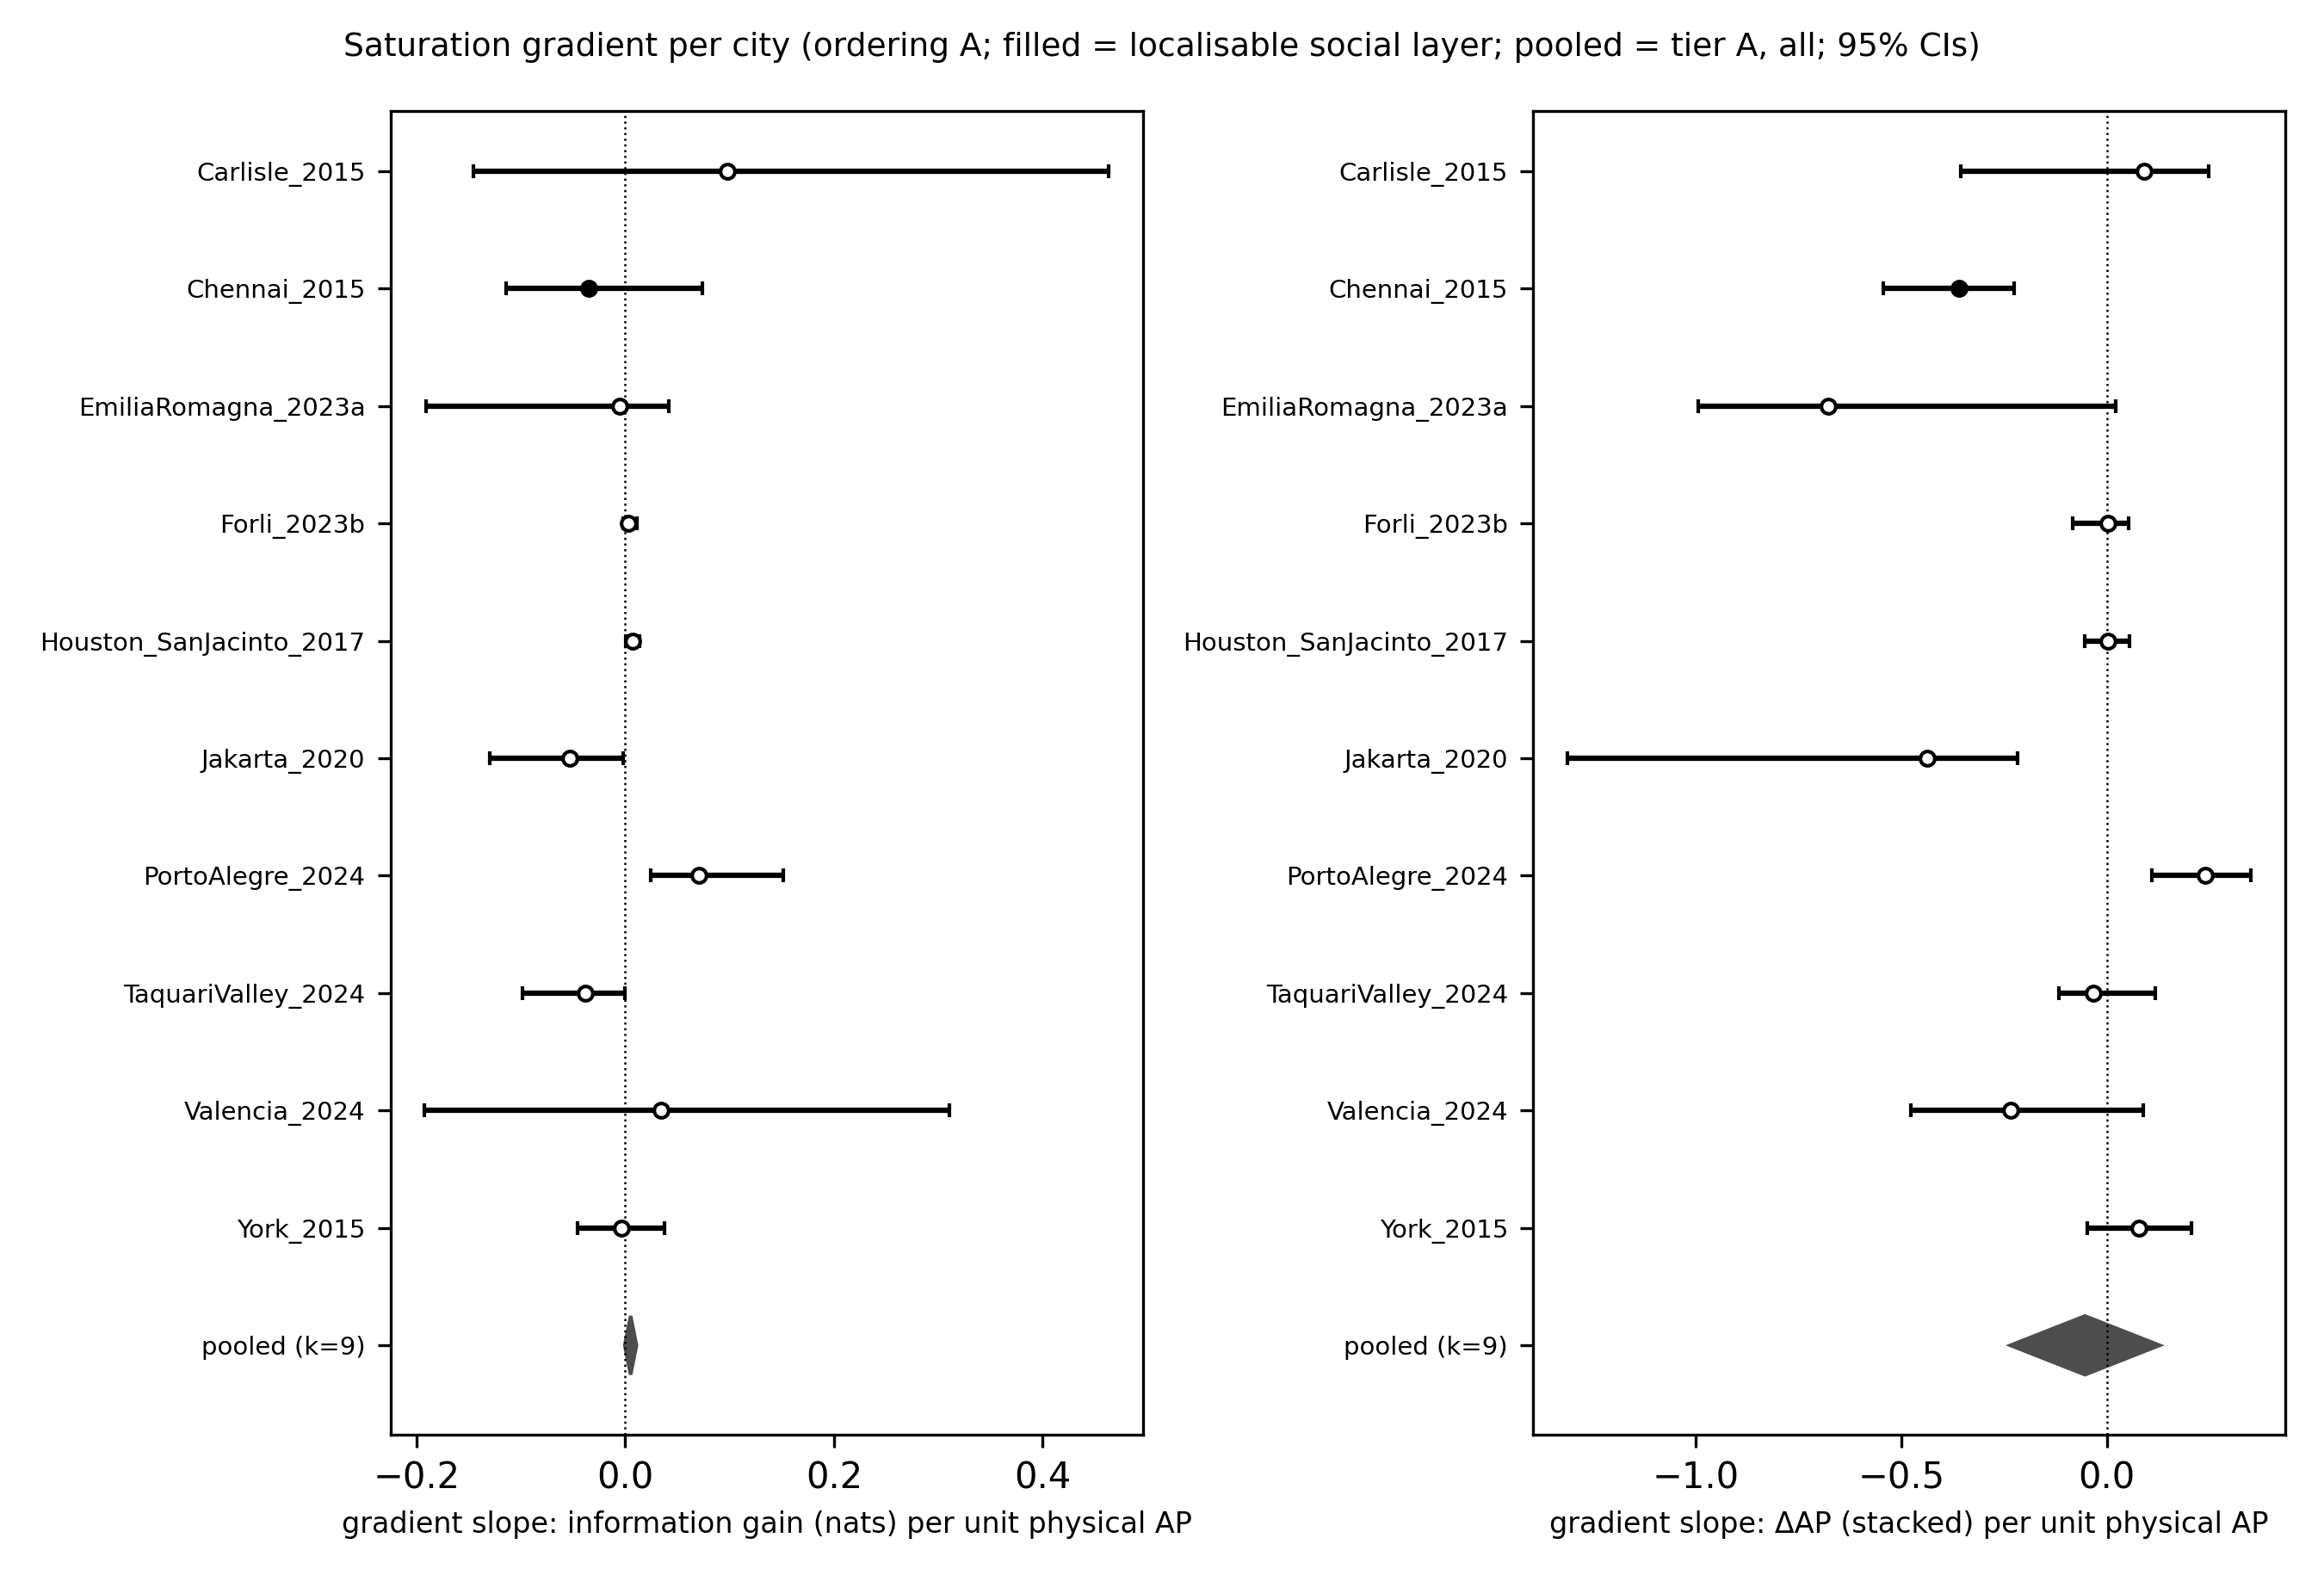

,time,session,city,stage,status,detail
5,2026-10-02T06:04:01,20261002T060319978366Z,Chennai_2015,gated:A_terrain_first,warn,80% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
10,2026-10-02T06:04:11,20261002T060319978366Z,Chennai_2015,gated:B_surface_first,warn,73% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
36,2026-10-02T06:08:04,20261002T060319978366Z,Valencia_2024,gated:A_terrain_first,warn,100% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gate...
41,2026-10-02T06:08:13,20261002T060319978366Z,Valencia_2024,gated:B_surface_first,warn,87% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
64,2026-10-02T06:11:32,20261002T060319978366Z,EmiliaRomagna_2023a,exclude,warn,"123,756 of 143,322 cells excluded (86.3%); 2576 flooded among 19,566 analysed"
68,2026-10-02T06:11:35,20261002T060319978366Z,EmiliaRomagna_2023a,gated:A_terrain_first,warn,50% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
73,2026-10-02T06:11:46,20261002T060319978366Z,EmiliaRomagna_2023a,gated:B_surface_first,warn,47% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
99,2026-10-02T06:15:09,20261002T060319978366Z,Forli_2023b,gated:A_terrain_first,warn,73% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
104,2026-10-02T06:15:18,20261002T060319978366Z,Forli_2023b,gated:B_surface_first,warn,50% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...
129,2026-10-02T06:18:36,20261002T060319978366Z,York_2015,gated:A_terrain_first,warn,93% of fold fits chose the edge of the gate grid (alpha=2.0 or tau=0.3); see the gated...


In [12]:
#@title 12 · Results at a glance
from IPython.display import Image, display
import glob, os, pandas as pd, orchestrator as orch
print(orch.PROFILES[RUN_PROFILE]["label"], "| mode:", RUN_MODE)
if RUN_MODE == "acquire":
    ov = f"{OUT_DIR}/acquisition_overview.csv"
    if os.path.exists(ov) and os.path.getsize(ov) > 5:
        display(pd.read_csv(ov))
    rows = []
    for c in CITIES_TO_RUN:
        p = f"{OUT_DIR}/{c}/{orch.INPUTS_FILE}.manifest.json"
        if os.path.exists(p):
            import json
            m = json.load(open(p)); rows.append(dict(city=c, MB=round(m["bytes"] / 1e6, 1), parts=m["parts"], sha256=m["sha256"][:12]))
    display(pd.DataFrame(rows))
    print("Acquisition finished for the cities above. Their inputs (parts <= 4.5 MB) are ready for RUN_MODE='analyse'.")
else:
    for r in CITY_RESULTS:
        if not r.get("results"):
            print(f"\n{r['city']}: FAILED -> {r.get('error')}  (see {OUT_DIR}/{r['city']}_ERROR.txt)"); continue
        print(f"\n===== {r['city']} | labels: {r['label_source']} | positives {r['positives']} | mentions {r['social'].get('mentions', 0)}")
        for ordering, res in r["results"].items():
            e = res.get("effects")
            if e is not None and len(e):
                print(f"-- {ordering}: effects at the most complete rung")
                display(e[e["rung"] == e["rung"].iloc[-1]][["metric", "estimate", "ci95_low", "ci95_high", "p_null", "verdict"]].round(4))
    syn = os.path.join(OUT_DIR, "paper_synthesis")
    if os.path.exists(os.path.join(syn, "RESULTS_SUMMARY.md")):
        print("\n================ CROSS-CITY SYNTHESIS (paper_synthesis/) ================")
        print(open(os.path.join(syn, "RESULTS_SUMMARY.md")).read()[:8000])
        for f in ["T9_localisation_audit.csv", "T8_meta_regression_localisation.csv", "T5_meta_top_rung.csv", "T3_meta_gradients.csv"]:
            p = os.path.join(syn, f)
            if os.path.exists(p) and os.path.getsize(p) > 5:
                try:
                    print(f"\n-- {f}"); display(pd.read_csv(p).round(4))
                except Exception as e_:
                    print(f"   not available yet ({type(e_).__name__})")
        if os.path.exists(os.path.join(syn, "fig_forest_gradients.png")):
            display(Image(os.path.join(syn, "fig_forest_gradients.png")))
display(LOG.frame().query("status in ['warn','fail']").tail(60))


### Troubleshooting
| Message | Meaning / action |
|---|---|
| `social sources OFF: [...]` | Those sources are unavailable or have no key; each city records it in `social_source_status.csv`. The run continues with real data from the others; nothing is imputed. |
| `rule t3: N gazetteer candidates rejected at acquisition` | Normal: parts of longer names (Montgomery *County*), countries/states, places placed elsewhere, common words, lower-case URL words. |
| `N documents -> M after de-duplication` | Syndicated wire copies and repeated texts/photos counted once (pre-registered). |
| `NOT eligible for the pooled gradient analysis` | The social layer is concentrated on few places. The city stays in the confirmatory (tier A, all) analysis; its localisation enters the moderator test. |
| `CV tile X m` | Spatial blocks sized from the label correlogram (pre-registered rule). Report per city (T1/provenance). |
| `GeoNames gazetteer unavailable … falling back to OSM` | Re-run acquisition for that city once GeoNames is reachable before using its results. |
| `inputs were acquired under pre-registration X, analysed under Y` | Re-acquire that city (cached stages reload quickly), then analyse. |
| `common-word lists … differ from the pre-registered ones` | Install exactly `wordfreq==3.1.1` (cell 1) and restart the runtime. |
| `SHA-256 … does not match the released code` | A file in `MyDrive/saturation_v6/code/` was edited or damaged; restore it from the release. |
| Disconnected mid-run | Re-run all cells; completed stages and rungs load from the cache. |
| `Earth Engine is required…` | Enable the Earth Engine API for `GCP_PROJECT` and register the project for Earth Engine. |
